# 🔋 UAV Battery Tool — Notebook 00: Battery Database & Pack Builder

This notebook lets you:
- Browse and filter the chemistry library, cell catalog, and battery pack catalog
- Compare cells and packs side-by-side
- Build a custom battery pack from any cell using S×P configuration
- Save custom packs back to `battery_db.xlsx`
- Visualise discharge curves at different C-rates and temperatures

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from batteries.database import BatteryDatabase
from batteries.builder  import build_pack, compare_configurations, pack_comparison_table
from batteries.discharge import (
    DischargeCurve, temperature_derate_factor, derated_capacity,
    peukert_capacity, available_c_rates, closest_c_rate
)

pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 160)
pd.set_option('display.float_format', '{:.2f}'.format)

DB_PATH = '../battery_db.xlsx'
db = BatteryDatabase(DB_PATH).load()
print(db.summary())

═══ Battery Database Summary ═══
  Chemistries       : 9
  Cells             : 11
  Battery packs     : 8
  Discharge points  : 132
  Equipment items   : 29
  UAV configurations: 3
  Mission profiles  : 3


---
## 1 · Chemistry Library

In [2]:
chem_rows = []
for c in db.chemistries.values():
    chem_rows.append({
        'ID': c.chem_id,
        'Name': c.name,
        'Code': c.short_code,
        'V nom': c.voltage_nominal,
        'V cut': c.voltage_cutoff,
        'Wh/kg': c.energy_density_wh_kg,
        'Wh/L': c.energy_density_wh_l,
        'W/kg': c.specific_power_w_kg,
        'Cycles': c.cycle_life,
        'T min': c.temp_min_c,
        'T max': c.temp_max_c,
        'Max C cont': c.max_cont_discharge_c,
        'Safety': c.safety_rating,
        'Cost': c.relative_cost,
    })
df_chem = pd.DataFrame(chem_rows).set_index('ID')
df_chem

,Name,Code,V nom,V cut,Wh/kg,Wh/L,W/kg,Cycles,T min,T max,Max C cont,Safety,Cost
ID,,,,,,,,,,,,,
LIPO,Lithium Polymer,LiPo,3.70,3.00,200.00,400.00,700.00,500,-20.00,60.00,30.00,Medium,Low
LION,Lithium Ion (NMC),Li-Ion,3.60,3.00,250.00,620.00,500.00,1000,-20.00,60.00,10.00,Medium,Low
LION21,Lithium Ion 21700 (NMC),Li-Ion,3.65,3.00,260.00,650.00,500.00,2000,-20.00,60.00,10.00,Medium,Low
LIFEPO4,Lithium Iron Phosphate,LFP,3.20,2.50,120.00,250.00,400.00,3000,-20.00,60.00,5.00,High,Medium
LITO,Lithium Titanate,LTO,2.40,1.80,80.00,160.00,900.00,20000,-40.00,65.00,10.00,Very High,High
SSS,Semi-Solid State (Li-Ion based),SSS,3.70,3.00,350.00,800.00,600.00,1000,-20.00,80.00,15.00,High,High
SOLID,All-Solid-State,SSB,3.80,3.00,400.00,900.00,700.00,2000,-20.00,100.00,10.00,Very High,Very High
NIMH,Nickel Metal Hydride,NiMH,1.20,0.90,100.00,300.00,200.00,500,-20.00,60.00,5.00,High,Medium
LIHV,High-Voltage LiPo (LiHV),LiHV,3.80,3.00,220.00,440.00,750.00,300,-10.00,60.00,25.00,Medium,Low


### Chemistry Radar — Energy density vs Power density vs Cycle life

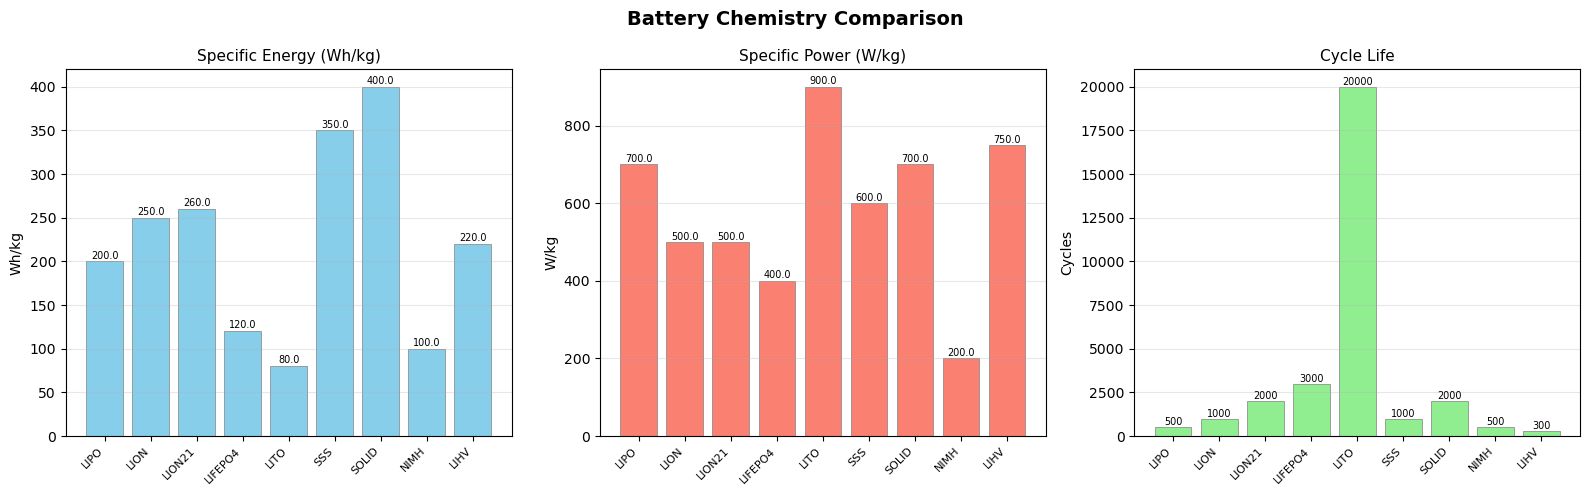

Saved chemistry_comparison.png


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Battery Chemistry Comparison', fontsize=14, fontweight='bold')

ids   = df_chem.index.tolist()
colors = plt.cm.tab10(np.linspace(0, 1, len(ids)))
x = np.arange(len(ids))

metrics = [
    ('Wh/kg', 'Specific Energy (Wh/kg)', 'skyblue'),
    ('W/kg',  'Specific Power (W/kg)',   'salmon'),
    ('Cycles','Cycle Life',              'lightgreen'),
]
for ax, (col, title, color) in zip(axes, metrics):
    bars = ax.bar(x, df_chem[col], color=color, edgecolor='grey', linewidth=0.5)
    ax.set_title(title, fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(ids, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel(col)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, df_chem[col]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                str(val), ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig('chemistry_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved chemistry_comparison.png')

---
## 2 · Cell Catalog

In [4]:
cell_rows = []
for c in db.cells.values():
    cell_rows.append({
        'Cell_ID': c.cell_id,
        'Manufacturer': c.manufacturer,
        'Model': c.model,
        'Chemistry': c.chemistry_id,
        'Format': c.cell_format,
        'V nom': c.voltage_nominal,
        'Capacity (Ah)': c.capacity_ah,
        'Energy (Wh)': c.energy_wh,
        'Weight (g)': c.weight_g,
        'Wh/kg': c.specific_energy_wh_kg,
        'I cont (A)': c.max_cont_discharge_a,
        'I pulse (A)': c.max_pulse_discharge_a,
        'C cont': c.max_cont_discharge_c,
        'IR (mΩ)': c.internal_resistance_mohm,
        'Cycles': c.cycle_life,
    })
df_cells = pd.DataFrame(cell_rows).set_index('Cell_ID')
df_cells

,Manufacturer,Model,Chemistry,Format,V nom,Capacity (Ah),Energy (Wh),Weight (g),Wh/kg,I cont (A),I pulse (A),C cont,IR (mΩ),Cycles
Cell_ID,,,,,,,,,,,,,,
TATTU_1300_4S,Tattu,Tattu 1300 4S,LIPO,Pouch,14.80,1.30,19.20,128.00,150.00,65.00,130.00,50.00,15.00,300
GAONENG_550,Gaoneng,GNB 550 HV,LIHV,Pouch,3.85,0.55,2.12,14.00,151.00,5.00,10.00,9.09,30.00,250
CNHL_5200,CNHL,Black Series 5200,LIPO,Pouch,3.70,5.20,19.20,148.00,130.00,52.00,156.00,10.00,10.00,200
SAMSUNG_30Q,Samsung SDI,INR18650-30Q,LION,18650 Cyl,3.60,3.00,10.80,48.50,223.00,15.00,20.00,5.00,28.00,500
SAMSUNG_40T,Samsung SDI,INR21700-40T,LION21,21700 Cyl,3.65,4.00,14.60,69.00,211.00,35.00,45.00,8.75,18.00,500
MOLICEL_P45B,Molicel,INR21700-P45B,LION21,21700 Cyl,3.65,4.50,16.40,70.00,234.00,45.00,90.00,10.00,14.00,800
LG_M50LT,LG Chem,INR21700-M50LT,LION21,21700 Cyl,3.63,5.00,18.20,70.50,258.00,14.00,20.00,2.80,22.00,500
A123_ANR26650,A123 Systems,ANR26650M1B,LIFEPO4,26650 Cyl,3.30,2.50,8.25,76.00,109.00,70.00,120.00,28.00,8.00,2000
HEADWAY_40152,Headway,HW 38120S,LIFEPO4,38120 Cyl,3.20,10.00,32.00,310.00,103.00,30.00,60.00,3.00,5.00,2000


In [5]:
# ── Filter: find best cells for a target specific energy ──────────────────────
MIN_WH_KG  = 200   # Wh/kg minimum
MIN_I_CONT = 20    # minimum continuous current (A)

filtered = df_cells[(df_cells['Wh/kg'] >= MIN_WH_KG) & (df_cells['I cont (A)'] >= MIN_I_CONT)]
print(f"Cells with ≥{MIN_WH_KG} Wh/kg AND ≥{MIN_I_CONT}A continuous:")
filtered[['Manufacturer','Model','Chemistry','Wh/kg','I cont (A)','Cycles']].sort_values('Wh/kg', ascending=False)

Cells with ≥200 Wh/kg AND ≥20A continuous:


,Manufacturer,Model,Chemistry,Wh/kg,I cont (A),Cycles
Cell_ID,,,,,,
MOLICEL_P45B,Molicel,INR21700-P45B,LION21,234.00,45.00,800
SAMSUNG_40T,Samsung SDI,INR21700-40T,LION21,211.00,35.00,500


---
## 3 · Battery Pack Catalog

In [6]:
pack_rows = []
for p in db.packs.values():
    pack_rows.append({
        'Pack_ID': p.battery_id,
        'Name': p.name,
        'Chemistry': p.chemistry_id,
        'Config': f'{p.cells_series}S{p.cells_parallel}P',
        'Voltage (V)': p.pack_voltage_nom,
        'Capacity (Ah)': p.pack_capacity_ah,
        'Energy (Wh)': p.pack_energy_wh,
        'Weight (g)': p.pack_weight_g,
        'Wh/kg': p.specific_energy_wh_kg,
        'Max I (A)': p.max_cont_discharge_a,
        'Max P (W)': p.max_cont_discharge_w,
        'C-rate': p.cont_c_rate,
        'Cycles': p.cycle_life,
        'UAV Class': p.uav_class,
    })
df_packs = pd.DataFrame(pack_rows).set_index('Pack_ID')
df_packs

,Name,Chemistry,Config,Voltage (V),Capacity (Ah),Energy (Wh),Weight (g),Wh/kg,Max I (A),Max P (W),C-rate,Cycles,UAV Class
Pack_ID,,,,,,,,,,,,,
BAT_FPV_4S1P,FPV Racing 4S 1300mAh,LIPO,4S1P,14.80,1.30,19.20,128.00,150.00,65.00,962.00,50.00,300,FPV / Racing
BAT_MICRO_1S,Micro UAV 1S 550mAh HV,LIHV,1S1P,3.85,0.55,2.12,14.00,151.00,5.00,19.00,9.00,250,Micro UAV
BAT_MID_6S2P,Mid UAV 6S2P 21700,LION21,6S2P,21.90,9.00,197.00,840.00,235.00,90.00,1971.00,10.00,800,Inspection UAV
BAT_MID_6S4P,Mid UAV 6S4P 21700 High Cap,LION21,6S4P,21.80,20.00,436.00,1692.00,258.00,56.00,1221.00,2.80,500,Long Endurance
BAT_AG_6S1P,Agriculture 6S LFP,LIFEPO4,6S1P,19.20,10.00,192.00,1860.00,103.00,30.00,576.00,3.00,2000,Agriculture UAV
BAT_HLIFT_6S2P,Heavy Lift 6S2P LFP,LIFEPO4,6S2P,19.80,5.00,99.00,912.00,109.00,140.00,2772.00,28.00,2000,Heavy Lift UAV
BAT_LE_12S2P,Long Endurance 12S2P 21700,LION21,12S2P,43.80,8.00,350.00,1656.00,212.00,70.00,3066.00,8.75,500,Fixed Wing VTOL
BAT_SSS_6S1P,Semi-Solid-State 6S1P,SSS,6S1P,22.20,5.00,111.00,606.00,183.00,12.00,266.00,2.40,800,Next-Gen UAV


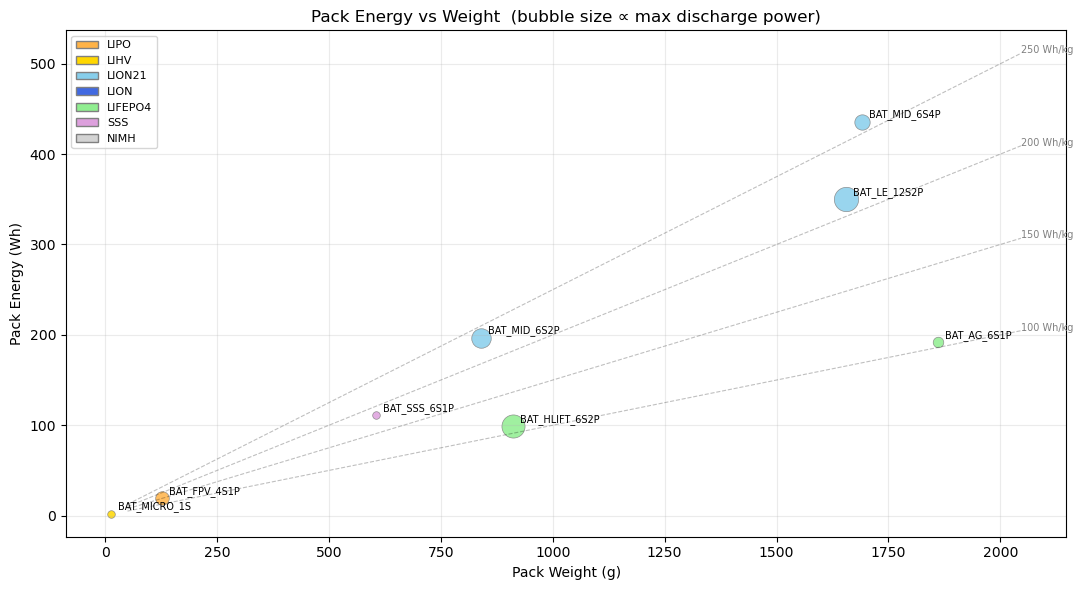

In [7]:
# Energy vs Weight scatter — size = max power
fig, ax = plt.subplots(figsize=(11, 6))
chem_palette = {
    'LIPO':'#FFB347','LIHV':'#FFD700','LION21':'#87CEEB',
    'LION':'#4169E1','LIFEPO4':'#90EE90','SSS':'#DDA0DD','NIMH':'#D3D3D3'
}
for _, row in df_packs.iterrows():
    color = chem_palette.get(row['Chemistry'], '#BBBBBB')
    size  = max(30, row['Max P (W)'] / 10)
    ax.scatter(row['Weight (g)'], row['Energy (Wh)'],
               s=size, c=color, alpha=0.85, edgecolors='grey', linewidth=0.5)
    ax.annotate(row.name, (row['Weight (g)'], row['Energy (Wh)']),
                textcoords='offset points', xytext=(5, 3), fontsize=7)

# Iso-Wh/kg lines
w_range = np.linspace(50, df_packs['Weight (g)'].max() * 1.1, 200)
for wh_kg in [100, 150, 200, 250]:
    ax.plot(w_range, wh_kg * w_range / 1000, '--', alpha=0.25,
            color='black', linewidth=0.8)
    ax.text(w_range[-1], wh_kg * w_range[-1] / 1000,
            f'{wh_kg} Wh/kg', fontsize=7, color='gray')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, edgecolor='grey', label=k)
                   for k, v in chem_palette.items()]
ax.legend(handles=legend_elements, loc='upper left', fontsize=8)

ax.set_xlabel('Pack Weight (g)')
ax.set_ylabel('Pack Energy (Wh)')
ax.set_title('Pack Energy vs Weight  (bubble size ∝ max discharge power)', fontsize=12)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig('pack_energy_weight.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 4 · Discharge Curve Visualisation

Available C-rates for LIPO: [0.5, 1.0, 2.0, 5.0]


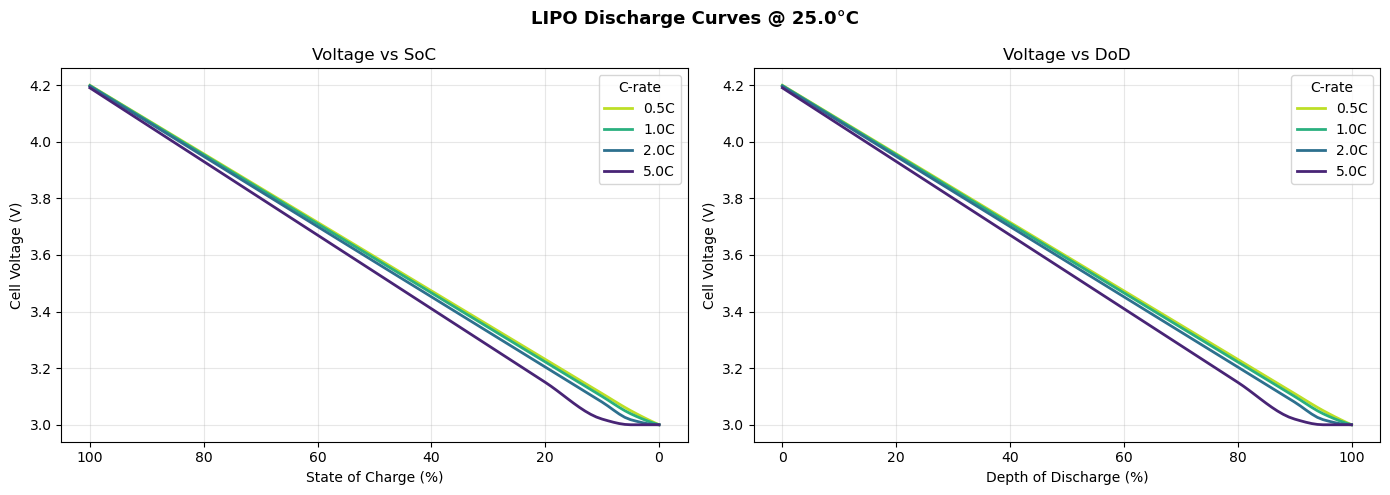

In [8]:
# ── Parameters ─────────────────────────────────────────────────────────────
CHEM_ID   = 'LIPO'    # Change to 'LION', 'LIFEPO4', etc.
C_RATES   = [0.5, 1.0, 2.0, 5.0]   # C-rates to plot
TEMP_C    = 25.0
# ───────────────────────────────────────────────────────────────────────────

avail = available_c_rates(db.discharge_pts, CHEM_ID)
print(f'Available C-rates for {CHEM_ID}: {avail}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'{CHEM_ID} Discharge Curves @ {TEMP_C}°C', fontsize=13, fontweight='bold')

colors = plt.cm.viridis_r(np.linspace(0.1, 0.9, len(C_RATES)))

for ax_idx, ax in enumerate(axes):
    for c_rate, color in zip(C_RATES, colors):
        try:
            cr_use = closest_c_rate(avail, c_rate)
            curve  = DischargeCurve(db.discharge_pts, CHEM_ID, cr_use, TEMP_C)
            socs   = curve.soc_array()
            volts  = curve.voltage_array()
            label  = f'{c_rate}C'
            if ax_idx == 0:
                ax.plot(socs, volts, color=color, label=label, linewidth=2)
            else:
                # Capacity axis (% of nominal)
                ax.plot([100 - s for s in socs], volts, color=color,
                        label=label, linewidth=2)
        except ValueError as e:
            print(f'  Skipping {c_rate}C: {e}')

axes[0].set_xlabel('State of Charge (%)')
axes[0].set_ylabel('Cell Voltage (V)')
axes[0].set_title('Voltage vs SoC')
axes[0].invert_xaxis()
axes[0].legend(title='C-rate')
axes[0].grid(alpha=0.3)

axes[1].set_xlabel('Depth of Discharge (%)')
axes[1].set_ylabel('Cell Voltage (V)')
axes[1].set_title('Voltage vs DoD')
axes[1].legend(title='C-rate')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'discharge_{CHEM_ID.lower()}.png', dpi=120, bbox_inches='tight')
plt.show()

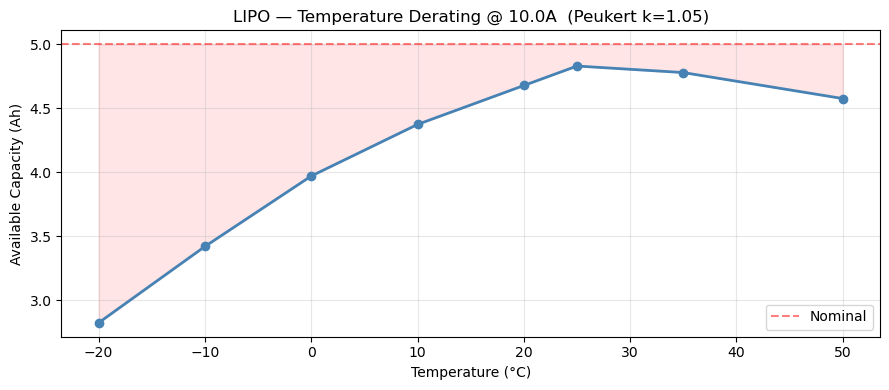

 Temp (°C)  Derated Capacity (Ah)  Factor
       -20                   2.83    0.56
       -10                   3.42    0.68
         0                   3.97    0.79
        10                   4.37    0.88
        20                   4.68    0.94
        25                   4.83    0.97
        35                   4.78    0.96
        50                   4.58    0.92


In [9]:
# Temperature derating curves
CHEM_DERATE = 'LIPO'
TEMPS       = [-20, -10, 0, 10, 20, 25, 35, 50]
CAP_NOM     = 5.0   # Ah nominal
I_DISC      = 10.0  # constant discharge current A

derations = []
for t in TEMPS:
    cap = derated_capacity(CAP_NOM, CHEM_DERATE, t, I_DISC, peukert_k=1.05)
    derations.append({'Temp (°C)': t, 'Derated Capacity (Ah)': round(cap, 3),
                      'Factor': round(cap / CAP_NOM, 3)})

df_derate = pd.DataFrame(derations)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(df_derate['Temp (°C)'], df_derate['Derated Capacity (Ah)'],
        'o-', color='steelblue', linewidth=2)
ax.axhline(CAP_NOM, linestyle='--', color='red', alpha=0.5, label='Nominal')
ax.fill_between(df_derate['Temp (°C)'], df_derate['Derated Capacity (Ah)'],
                CAP_NOM, alpha=0.1, color='red')
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Available Capacity (Ah)')
ax.set_title(f'{CHEM_DERATE} — Temperature Derating @ {I_DISC}A  (Peukert k=1.05)', fontsize=12)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('temperature_derating.png', dpi=120, bbox_inches='tight')
plt.show()
print(df_derate.to_string(index=False))

---
## 5 · Custom Pack Builder

Define your cell and S×P configuration — all electrical and physical specs are calculated automatically.

In [10]:
# ── ① Choose your base cell ────────────────────────────────────────────────
CELL_ID      = 'MOLICEL_P45B'   # Must exist in Cell_Catalog — or define below

# ── ② Pack configuration ──────────────────────────────────────────────────
SERIES       = 6      # cells in series  (sets pack voltage)
PARALLEL     = 2      # cells in parallel (sets pack capacity)
OVERHEAD_PCT = 12.0   # BMS + wiring + enclosure weight overhead (%)
VOLUME_FACTOR= 1.30   # packing factor: pack vol / sum of cell volumes
PACK_ID      = ''     # leave blank to auto-generate
UAV_CLASS    = 'Inspection UAV'
NOTES        = 'Custom 6S2P Molicel P45B build'

# ── Build ──────────────────────────────────────────────────────────────────
cell = db.cells[CELL_ID]
pack = build_pack(
    cell=cell,
    series=SERIES,
    parallel=PARALLEL,
    overhead_pct=OVERHEAD_PCT,
    volume_factor=VOLUME_FACTOR,
    pack_id=PACK_ID,
    uav_class=UAV_CLASS,
    notes=NOTES,
)

print('='*55)
print(f' Custom Pack: {pack.battery_id}')
print('='*55)
print(f'  Cell              : {cell.manufacturer} {cell.model}')
print(f'  Configuration     : {SERIES}S × {PARALLEL}P = {pack.total_cells} cells')
print(f'  Nominal voltage   : {pack.pack_voltage_nom:.2f} V')
print(f'  Max voltage       : {pack.pack_voltage_max:.2f} V')
print(f'  Cutoff voltage    : {pack.pack_voltage_cutoff:.2f} V')
print(f'  Capacity          : {pack.pack_capacity_ah:.2f} Ah')
print(f'  Energy            : {pack.pack_energy_wh:.1f} Wh')
print(f'  Pack weight       : {pack.pack_weight_g:.0f} g  ({pack.pack_weight_g/1000:.3f} kg)')
print(f'  Specific energy   : {pack.specific_energy_wh_kg:.1f} Wh/kg')
if pack.pack_volume_cm3:
    print(f'  Volume            : {pack.pack_volume_cm3:.0f} cm³')
if pack.energy_density_wh_l:
    print(f'  Energy density    : {pack.energy_density_wh_l:.0f} Wh/L')
print(f'  Max cont. current : {pack.max_cont_discharge_a:.0f} A')
print(f'  Max cont. power   : {pack.max_cont_discharge_w:.0f} W')
print(f'  C-rate (cont.)    : {pack.cont_c_rate:.2f}C')
print(f'  Internal resist.  : {pack.internal_resistance_mohm:.2f} mΩ')
print(f'  Cycle life        : {pack.cycle_life} cycles')
print('='*55)

 Custom Pack: CUSTOM_MOLICEL_P45B_6S2P
  Cell              : Molicel INR21700-P45B
  Configuration     : 6S × 2P = 12 cells
  Nominal voltage   : 21.90 V
  Max voltage       : 25.20 V
  Cutoff voltage    : 15.00 V
  Capacity          : 9.00 Ah
  Energy            : 197.1 Wh
  Pack weight       : 941 g  (0.941 kg)
  Specific energy   : 209.5 Wh/kg
  Volume            : 530 cm³
  Energy density    : 372 Wh/L
  Max cont. current : 90 A
  Max cont. power   : 1971 W
  C-rate (cont.)    : 10.00C
  Internal resist.  : 42.00 mΩ
  Cycle life        : 800 cycles


In [11]:
# Compare multiple configurations of the same cell
CELL_COMPARE  = 'MOLICEL_P45B'
CONFIGS       = [(4,1),(4,2),(6,1),(6,2),(6,3),(8,2),(12,1)]

cell_cmp = db.cells[CELL_COMPARE]
packs_cmp = compare_configurations(cell_cmp, CONFIGS)
df_compare = pd.DataFrame(pack_comparison_table(packs_cmp))
print(f'Configuration comparison — {cell_cmp.manufacturer} {cell_cmp.model}')
df_compare

Configuration comparison — Molicel INR21700-P45B


,ID,Config,Voltage (V),Capacity (Ah),Energy (Wh),Weight (g),Sp. Energy (Wh/kg),Max I cont (A),Max P cont (W),C-rate cont,IR (mΩ),Cycles
0,CUSTOM_MOLICEL_P45B_4S1P,4S1P,14.60,4.50,65.70,313.60,209.50,45.00,657.00,10.00,56.00,800
1,CUSTOM_MOLICEL_P45B_4S2P,4S2P,14.60,9.00,131.40,627.20,209.50,90.00,1314.00,10.00,28.00,800
2,CUSTOM_MOLICEL_P45B_6S1P,6S1P,21.90,4.50,98.50,470.40,209.50,45.00,985.00,10.00,84.00,800
3,CUSTOM_MOLICEL_P45B_6S2P,6S2P,21.90,9.00,197.10,940.80,209.50,90.00,1971.00,10.00,42.00,800
4,CUSTOM_MOLICEL_P45B_6S3P,6S3P,21.90,13.50,295.60,1411.20,209.50,135.00,2956.00,10.00,28.00,800
5,CUSTOM_MOLICEL_P45B_8S2P,8S2P,29.20,9.00,262.80,1254.40,209.50,90.00,2628.00,10.00,56.00,800
6,CUSTOM_MOLICEL_P45B_12S1P,12S1P,43.80,4.50,197.10,940.80,209.50,45.00,1971.00,10.00,168.00,800


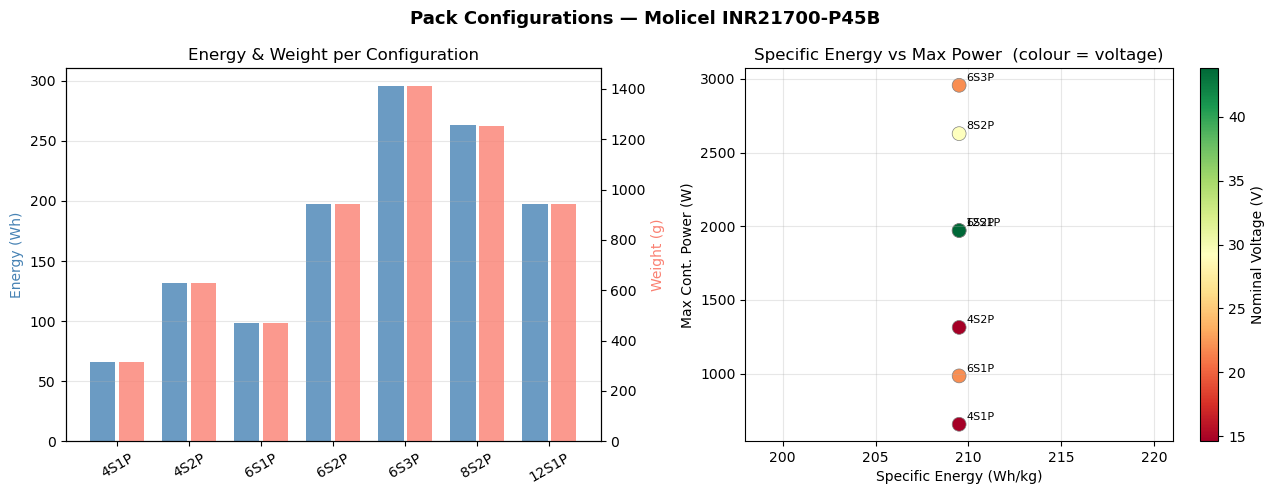

In [12]:
# Visualise energy vs weight for all configurations
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'Pack Configurations — {cell_cmp.manufacturer} {cell_cmp.model}',
             fontsize=13, fontweight='bold')

labels = [f'{s}S{p}P' for s, p in CONFIGS]
energies = [p.pack_energy_wh for p in packs_cmp]
weights  = [p.pack_weight_g  for p in packs_cmp]
voltages = [p.pack_voltage_nom for p in packs_cmp]

x = np.arange(len(labels))

# Energy & weight
ax1, ax2_twin = axes[0], axes[0].twinx()
bars = ax1.bar(x - 0.2, energies, 0.35, label='Energy (Wh)', color='steelblue', alpha=0.8)
bars2= ax2_twin.bar(x + 0.2, weights, 0.35, label='Weight (g)', color='salmon', alpha=0.8)
ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=30)
ax1.set_ylabel('Energy (Wh)', color='steelblue')
ax2_twin.set_ylabel('Weight (g)', color='salmon')
ax1.set_title('Energy & Weight per Configuration')
axes[0].grid(axis='y', alpha=0.3)

# Specific energy by config
sp_en = [p.specific_energy_wh_kg for p in packs_cmp]
c_rate= [p.cont_c_rate for p in packs_cmp]

scatter = axes[1].scatter(sp_en, [p.max_cont_discharge_w for p in packs_cmp],
                          s=100, c=voltages, cmap='RdYlGn', edgecolors='grey', linewidth=0.5)
for i, lbl in enumerate(labels):
    axes[1].annotate(lbl, (sp_en[i], packs_cmp[i].max_cont_discharge_w),
                     textcoords='offset points', xytext=(5, 3), fontsize=8)
plt.colorbar(scatter, ax=axes[1], label='Nominal Voltage (V)')
axes[1].set_xlabel('Specific Energy (Wh/kg)')
axes[1].set_ylabel('Max Cont. Power (W)')
axes[1].set_title('Specific Energy vs Max Power  (colour = voltage)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('pack_configurations.png', dpi=120, bbox_inches='tight')
plt.show()

In [13]:
# ── Save pack to Excel catalog (optional) ─────────────────────────────────
SAVE_TO_DB = False   # Set True to write to battery_db.xlsx

if SAVE_TO_DB:
    db.append_custom_pack(pack)
    print(f'✓ Pack saved to {DB_PATH}')
else:
    print('Set SAVE_TO_DB = True to persist the pack to battery_db.xlsx')

Set SAVE_TO_DB = True to persist the pack to battery_db.xlsx
